In [ ]:
import sys
sys.path.insert(0, '../src')

import priceModels as pm
import amOptPricer as aop

import numpy as np
import matplotlib.pyplot as plt

## Improved Stein-Stein (LLH) model of the price dynamics

\begin{align}
    \frac{dS_t}{S_t} &= rdt + \sigma_tdW^1_t\\
    d\sigma_t &= \kappa(\theta_t-\sigma_t)dt + \nu dW^2_t\\
    d\theta_t &= \lambda dt + \eta dB_t\\
    dB_t &= B_t dW_t,\,B_0=1\\
    \text{ }\notag\\
    \text{cov}&(W^1_t,W^2_t)=\rho t \notag
\end{align}

- $W^1_t,\,W^2_t$ are correlated brownian motions, $W_t$ independent brownian motion
- $\Theta = (\kappa,\,\nu,\,\lambda,\,\eta,\, \rho)$ are the model parameters

#### 1. Simulate Price Paths

We illustrate how to simulate price paths from the LLH model using Algorithm 2.5 detailed in the report. The values of the model parameters have been selected from the Lin-Lin-He paper, Table 2. Ten thousand paths have been sampled over a 1 year horizon with 252 trading days.

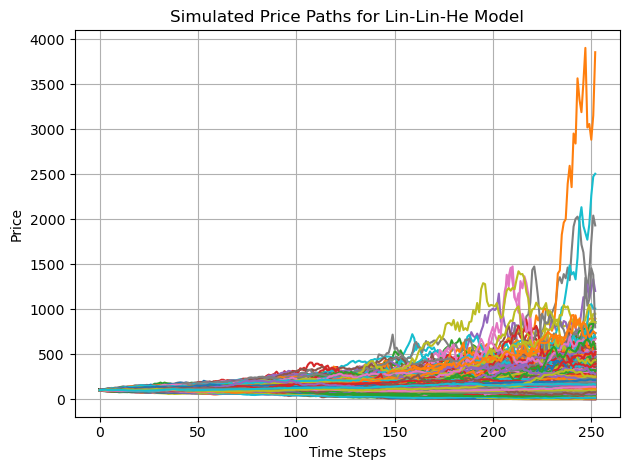

In [2]:
#r=0.3943,  kappa=4.9394, nu=0.4, sigma0=0.2924, theta0=0.1319, lam=0.3115, eta=0.4112, rho=0.1691 from the Lin-Lin-He papaer Table 2
model_llh = pm.ImprovedSteinStein(
        r=0.3943, rho=0.1691, kappa=4.9394, nu=0.4,
        sigma0=0.2924, theta0=0.1319, lam=0.3115, eta=0.4112, seed=123
    )

# Simulate 10,000 paths for 1 year horizon (T=1.0) with 252 trading days
res_llh = model_llh.simulate_prices(S0=100.0, T=1.0, n_steps_mc=252, n_paths= 10000)

# Plot the simulated price paths
pm.plot(res_llh['S'].T, title="Simulated Price Paths for Lin-Lin-He Model")

#### 2. Compute European Prices

We illustrate the computation of European options using the algorithm outlined in section 3.1 of the report (the "exact" LLH formula of the European price). Furthermore, we perform a Monte Carlo simulation of $1 ,000,000$ paths to estimate the price of vanilla european options under the LLH model and we compare the results with the results of the LLH price formula.

- Consider a 1 month horizon ($T = 0.083$ yr) with 22 trading days. 

In [ ]:
pm.compare_european_prices(model_llh, S0=100.0, K=90.0, tau=0.083, n_steps_mc=22, n_paths=1000000, phi_max=1000, n_phi=2500,n_steps_ode=5000)

- Consider a 1 year horizon with 252 trading days. 

In [ ]:
pm.compare_european_prices(model_llh, S0=100.0, K=90.0, tau=1.0, n_steps_mc=52, n_paths=50000, phi_max=1000, n_phi=2500, n_steps_ode=5000)

European call LLH price:  40.63737846053636,
European call MC price:  46.77476791848234, MC 95% CI: (46.307397633883696, 47.242138203080984),
European put LLH price:  1.3110386935186895,
European put MC price:  7.448428151464668


#### Remarks
- Recall the call-put parity: $P-C=Ke^{-t\tau}-S$ which implies that $P_E^{llh}-P^{MC}_E=C_E^{llh}-C^{MC}_E$
- Notice the bias in the LLH price that accentuates with longer maturity. The implementation of the "exact" LLH price seems to be consistently underevaluating the euporean price. The bias is due to the errors that result from the estimation of the ODE system and the integrals involved in the LLH formula. Further investigation is required.

#### 3. Compute American Put Price 

We illustrate the computation of the american put price following the LSM algorithm with variance reduction using the european LLH price as a control variate. The Algorithm is outlined in section 3.2.1 of the report. We limit the number of simulated paths to $1000$ in order to accomodate for the computational cost of the propsed approach. 

We consider the pricing of an american put with strike $K=90.0$, spot price $S=100.0$, $1$ year maturity period with $52$ possible exercise dates. We follow that with the pricing of a similar option but whose maturity is $1$ a month  period with $22$ possible exercise dates. In either case, the LSM price undervalues the put, and actually violates the fundamental inequality: $P_E<P_A$ for options with similar specs. 

#### 3.1 American put 1 year maturity and 52 exercise dates

In [5]:
# # Simulate 1,000 paths for 1 month horizon (T=0.083) with 22 trading days
# res_llh = model_llh.simulate_prices(S0=100.0, T=0.083, n_steps_mc=22, n_paths= 1000)

# # American put via LSM + Rasmussen CV (european LLH price)
# res = aop.price_american_put_lsm_llh(model_llh, res_llh, K=90.0, basis_order=3, 
#                                      use_cv=True, improved=True, ridge=1e-5,
#                                      euro_method='llh'
# )
# #print(f"American put LSM-Rcv price: {res.get('price')},\nci95: {res.get('ci_95')}")

In [15]:
# pm.compare_european_prices(model_llh, S0=100.0, K=90.0, tau=1.0, n_steps_mc
# =252, n_paths= 50000)

European call LLH price:  39.48124788309429,
European call MC price:  46.984913741992706, MC 95% CI: (46.376887844033924, 47.59293963995149),
European put LLH price:  0.15490811607661925,
European put MC price:  7.658573974975035


In [9]:
print(f"American put LSM-Rcv price: {res.get('price')},\nci95: {res.get('ci_95')}")

American put LSM-Rcv price: 0.011284637014341408,
ci95: (-0.0015883458216743133, 0.02415761985035713)


Recall,  $P_E^{llh}-P^{MC}_E=C_E^{llh}-C^{MC}_E$

#### 3.2 American put 1 month maturity and 22 exercise dates

In [11]:
# American put via LSM + Rasmussen CV (european LLH price)
res_llh = model_llh.simulate_prices(S0=100.0, T=0.083, n_steps_mc=22, n_paths= 1000)
res = aop.price_american_put_lsm_llh(model_llh, res_llh, K=90.0, basis_order=3, 
                                     use_cv=True, improved=True, ridge=1e-5,
                                     euro_method='llh'
)

print(f"American put LSM-Rcv price: {res.get('price')},\nci95: {res.get('ci_95')}")

American put LSM-Rcv price: 0.011284637014341408,
ci95: (-0.0015883458216743133, 0.02415761985035713)


In [34]:
pm.compare_european_prices(model_llh, S0=100.0, K=90.0, tau=0.083, n_steps_mc=22, n_paths= 50000)

European call LLH price:  12.89755594052751,
European call MC price:  13.550328551139396, MC 95% CI: (13.492156839660598, 13.608500262618193),
European put LLH price:  -0.0001893185944936704,
European put MC price:  0.6525832920173968


#### Remarks
- Notice that $P^{lsm}_A<P^{llh}_E$, where the former entity is the american put price using the LSM with variance reduction and the latter is the european put price obtained using the LLH formula.

- Similarly $P^{lsm}_A<P^{MC}_E$, where the latter entity is the european put price obtained using the MC.

#### 4. Recompute the LSM price with control variate the MC European price

In [35]:
# American put via LSM + CV (european MC price)
res = aop.price_american_put_lsm_llh(model_llh, res_llh, K=90.0, basis_order=3, 
                                     use_cv=True, improved=True, ridge=1e-5,
                                     euro_method='mc1'
)

print(f"American put LSM-MCcv price: {res.get('price')},\nci95: {res.get('ci_95')}")

American put LSM-MCcv price: 0.052954552932568545,
ci95: (0.03091844636757233, 0.07499065949756475)


## Validate the Implementation on edge Cases 

### 1. Black-Scholes limit: $\kappa=\nu=\lambda=\eta=\rho=0$

#### 1.1 Simulate Price Paths

In [5]:
# BS limit: no volatility dynamics kappa=nu=lambda=eta=rho=0 → price is Log-Normal
model_bs_limit = pm.ImprovedSteinStein(
        r=0.05, rho=0.0, kappa=0.0, nu=0.0,
        sigma0=0.2, theta0=0.0, lam=0.0, eta=0.0, seed=123
    )

res_bs = model_bs_limit.simulate_prices(S0=100.0, T=1.0, n_steps_mc=252, n_paths= 10000)
pm.plot(res_bs['S'].T, title="Simulated Price Paths for the Black-Scholes Limit")

ZeroDivisionError: float division by zero

#### Test of Lognormality of the generated price paths

We draw price paths from the LLH (BS-limit) model and consider the price slice at the end of the simulation horizon $T$. The distribution of the  price slice  should match the BS distribution at time $T$, that is a log normal distribution. We test this hypothesis by using a utility function from the priceModles module.

In [6]:
pm.test_lognormality(res_bs['S'][:,-1])

KS statistic: 0.0051, p-value: 0.9547
Fail to reject null: data may be lognormal.


#### 1.2 Compare European Option Prices

Compare the LLH (BS-limit) formula price with the BS call price and with the Monte Carlo price.

In [7]:
# BS limit → price must match Black–Scholes
S, K, tau, vol, theta = 100,90,1.0,0.2, 0.0
price_llh = model_bs_limit.price_call_llh(S, K, tau, vol, theta).item()  

# Black–Scholes benchmark:
price_bs = aop.price_call_bs(S=100, K=90, tau=1.0, r=0.05, vol=0.2)

# Monte Carlo pricing using the simulated paths
price_mc = aop.price_call_mc(res_bs['S'], K=90, T=1.0, r=0.05).get('price')
print(f"Improved Stein-Stein (BS-limit) = {price_llh:.10f},\nBlack-Scholes = {price_bs:.10f},\n|Δ| = {abs(price_llh-price_bs):.3e},\nMonte Carlo = {price_mc:.10f}")

Improved Stein-Stein (BS-limit) = 16.6994484084,
Black-Scholes = 16.6994484084,
|Δ| = 5.684e-14,
Monte Carlo = 16.5898217133


#### 1.3 Compare American Put Prices

Compare the price of the LSM algortihm/control variate the LLH (BS limit) price with the Black-Scholes put price

In [ ]:
# Simulate 1000 paths for 1 month horizon (T=0.083) with 22 trading days
res_bs_limit = model_bs_limit.simulate_prices(S0=100.0, T=0.083, n_steps_mc=22, n_paths= 1000)

# American put via LSM + Rasmussen CV (LLH BS-limit price as control variate)
res = aop.price_american_put_lsm_llh(model_bs_limit, res_bs_limit, K=90.0,
                                     basis_order=3,  ridge=1e-5,
                                     use_cv=True, improved=True,
                                     euro_method='llh')

In [10]:
# Black–Scholes benchmark:
r=0.05; tau=0.083
price_bs = aop.price_call_bs(S=100, K=90, tau=0.083, r=0.05, vol=0.2)
price_put_bs = price_bs - S + K * np.exp(-r * tau)

print(f"Black-Scholes = {price_put_bs:.10f},\nImproved Stein-Stein (BS-limit) = {res['price']:.10f},\nci95: {res['ci_95']}")

Black-Scholes = 0.0601901112,
Improved Stein-Stein (BS-limit) = 2.4689238877,
ci95: (2.3802457542298114, 2.557602021143115)


#### Remark
The computed prices are satisfactorly close. However, notice the downward bias in the price of the LSM algorithm ( a lower bound estimate!) 

#### 1.4 Recompute the LSM price with control variate the BS european price

The rationale is that the LLH formula price in the case of the Black-Scholes limit of the model should coincide with the Black-Scholes price

In [11]:
# American put via LSM + Rasmussen CV (BS european price as control variate)
res = aop.price_american_put_lsm_llh(model_bs_limit, res_bs, K=90.0, 
                                     basis_order=3, ridge=1e-5,
                                     use_cv=True, improved=True,  
                                     euro_method='bs')

print(f"Black-Scholes = {price_put_bs:.10f},\nImproved Stein-Stein (BS-limit) = {res['price']:.10f},\nci95: {res['ci_95']}")

Black-Scholes = 0.0601901112,
Improved Stein-Stein (BS-limit) = 2.4689238877,
ci95: (2.3802457542298114, 2.557602021143115)


### 2. Stein-Stein limit:  $\lambda=\eta=\rho=0$

#### 2.1 Simulate Price Paths

In the Stein-Stein paper:
$\delta = \kappa =4, \quad k = \nu = 0.1,\quad \mu = r = 0.0953, \quad \sigma = vol = 0.2$


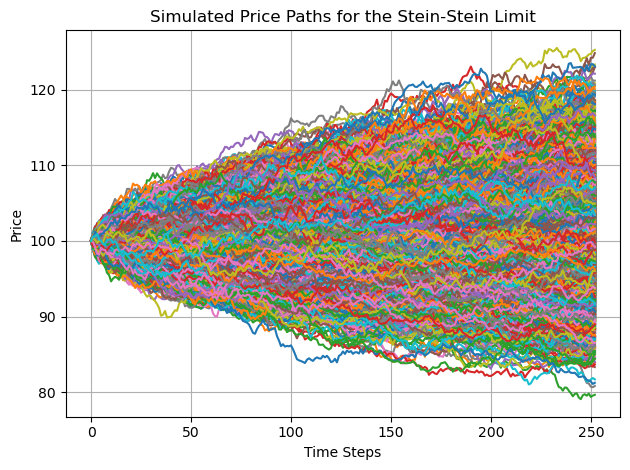

In [6]:
# Stein-Stein limit: rho=0.0, lam=0.0, eta=0.0 
# Param values and option price taken from  the Stein-Stein paper Table 1; 
#r=0.0953,  kappa=4.0, nu=0.1, sigma0=0.2, theta0=0.2

# Stein-Stein limi → price must match Stein-Stein
model_ss_limit = pm.ImprovedSteinStein(
        r=0.0953, rho=0.0, kappa=4.0, nu=0.1,
        sigma0=0.2, theta0=0.2, lam=0.0, eta=0.0, seed=123
    )

res_ss = model_ss_limit.simulate_prices(S0=100.0, T=1.0/12, n_steps_mc=252, n_paths= 10000)

pm.plot(res_ss['S'].T, title="Simulated Price Paths for the Stein-Stein Limit")

#### 2.2 Compare European Option prices

In [7]:
# SS limit→ price must match Stein-Stein
S, K, tau, vol, theta = 100,90,1/12,0.2, 0.2
price_llh = model_ss_limit.price_call_llh(S, K, tau, vol, theta)  



In [8]:
price_llh = price_llh.item()

In [9]:
# Stein-Stein benchmark:
price_ss = 10.77 # from the Stein-Stein paper Table 1
print(f"Prototype (SS-limit) = {price_llh:.10f},  Stein-Stein = {price_ss:.10f},  |Δ| = {abs(price_llh-price_ss):.3e}")

# Monte Carlo pricing using the simulated paths
price_mc = aop.price_call_mc(res_ss['S'], K=90, T=.0/12, r=0.0953)['price']
print(f"Monte Carlo price= {price_mc:.10f}")

Prototype (SS-limit) = 10.7668609302,  Stein-Stein = 10.7700000000,  |Δ| = 3.139e-03
Monte Carlo price= 10.8147914088


#### 2.3 Compare American Option Prices

In [12]:
lam = lambda k: (1 - np.exp(-k)) / k
k_grid = np.arange(-1e-10, 1e-5, 1e-9)
vals = np.array([lam(k) for k in k_grid])

In [13]:
vals


array([1.00000008, 0.99999996, 1.00000002, ..., 0.999995  , 0.999995  ,
       0.999995  ])